# 🤖 Treinamento Multirregional com ResNet18 (Uma para cada região facial)

In [ ]:
# 📦 Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import classification_report

In [ ]:
import torch
print(torch.version.cuda)  
print(torch.cuda.is_available()) 
print(torch.cuda.get_device_name(0)) 

In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import classification_report

# Configurações
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
REGIONS = ["forehead", "chin", "nose", "left_cheek", "right_cheek"]
BASE_PATH = "../../data/final"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Criar diretório para modelos
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
model_dir = os.path.join(parent_dir, "models")
os.makedirs(model_dir, exist_ok=True)

# 🔁 Treinamento por região
for region in REGIONS:
    print(f"\n🌍 Região: {region}")

    # Transformações
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor()
    ])

    train_dir = os.path.join(BASE_PATH, region, 'train')
    val_dir = os.path.join(BASE_PATH, region, 'val')
    test_dir = os.path.join(BASE_PATH, region, 'test')

    # Datasets e loaders
    train_ds = datasets.ImageFolder(train_dir, transform=transform)
    val_ds = datasets.ImageFolder(val_dir, transform=transform)
    train_ds = ConcatDataset([train_ds, val_ds])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    test_transform = transforms.Compose([
        transforms.ToTensor()
    ])
    test_ds = datasets.ImageFolder(test_dir, transform=test_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Modelo
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 4)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    # Treinamento
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        pbar = tqdm(train_loader, desc=f"{region} | Epoch {epoch+1}/{EPOCHS}")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'Loss': running_loss / (total / BATCH_SIZE), 'Acc': 100. * correct / total})

    # Avaliação
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n📊 Classificação para região: {region}")
    print(classification_report(all_labels, all_preds, target_names=['0', '1', '2', '3']))

    # Salvar modelo
    model_path = os.path.join(model_dir, f"resnet18_{region}_final.pth")
    torch.save(model.state_dict(), model_path)
    print(f"💾 Modelo salvo: {model_path}")



🌍 Região: forehead


forehead | Epoch 1/30: 100%|██████████| 17/17 [00:01<00:00, 16.09it/s, Loss=0.851, Acc=63.6]
forehead | Epoch 2/30: 100%|██████████| 17/17 [00:00<00:00, 22.17it/s, Loss=0.462, Acc=84.8]
forehead | Epoch 3/30: 100%|██████████| 17/17 [00:00<00:00, 22.51it/s, Loss=0.331, Acc=88.5]
forehead | Epoch 4/30: 100%|██████████| 17/17 [00:00<00:00, 22.82it/s, Loss=0.219, Acc=93.3]
forehead | Epoch 5/30: 100%|██████████| 17/17 [00:00<00:00, 22.82it/s, Loss=0.178, Acc=94.8]
forehead | Epoch 6/30: 100%|██████████| 17/17 [00:00<00:00, 22.67it/s, Loss=0.164, Acc=94.4]
forehead | Epoch 7/30: 100%|██████████| 17/17 [00:00<00:00, 22.44it/s, Loss=0.112, Acc=97]  
forehead | Epoch 8/30: 100%|██████████| 17/17 [00:00<00:00, 22.82it/s, Loss=0.0995, Acc=96.3]
forehead | Epoch 9/30: 100%|██████████| 17/17 [00:00<00:00, 22.60it/s, Loss=0.0665, Acc=97.8]
forehead | Epoch 10/30: 100%|██████████| 17/17 [00:00<00:00, 22.72it/s, Loss=0.0509, Acc=98.9]
forehead | Epoch 11/30: 100%|██████████| 17/17 [00:00<00:00, 22.03


📊 Classificação para região: forehead
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       1.00      0.95      0.98        21
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00        50

    accuracy                           0.98        93
   macro avg       0.97      0.94      0.95        93
weighted avg       0.98      0.98      0.98        93

💾 Modelo salvo: c:\Users\GonLu\Documents\Projetos\pibic_final\training\models\resnet18_forehead_final.pth

🌍 Região: chin


chin | Epoch 1/30: 100%|██████████| 79/79 [00:03<00:00, 22.03it/s, Loss=1.18, Acc=46.3]
chin | Epoch 2/30: 100%|██████████| 79/79 [00:03<00:00, 22.31it/s, Loss=0.982, Acc=55]  
chin | Epoch 3/30: 100%|██████████| 79/79 [00:03<00:00, 22.31it/s, Loss=0.887, Acc=61.4]
chin | Epoch 4/30: 100%|██████████| 79/79 [00:03<00:00, 22.26it/s, Loss=0.788, Acc=65.7]
chin | Epoch 5/30: 100%|██████████| 79/79 [00:03<00:00, 22.01it/s, Loss=0.697, Acc=70.9]
chin | Epoch 6/30: 100%|██████████| 79/79 [00:03<00:00, 22.22it/s, Loss=0.57, Acc=77.1] 
chin | Epoch 7/30: 100%|██████████| 79/79 [00:03<00:00, 21.76it/s, Loss=0.489, Acc=80.3]
chin | Epoch 8/30: 100%|██████████| 79/79 [00:03<00:00, 21.74it/s, Loss=0.439, Acc=82.7]
chin | Epoch 9/30: 100%|██████████| 79/79 [00:03<00:00, 21.62it/s, Loss=0.355, Acc=86.4]
chin | Epoch 10/30: 100%|██████████| 79/79 [00:03<00:00, 21.36it/s, Loss=0.34, Acc=88.2] 
chin | Epoch 11/30: 100%|██████████| 79/79 [00:03<00:00, 21.46it/s, Loss=0.291, Acc=89.9]
chin | Epoch 12/30: 


📊 Classificação para região: chin
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       102
           1       0.94      0.94      0.94       139
           2       0.95      0.92      0.93        38
           3       0.96      0.98      0.97        50

    accuracy                           0.95       329
   macro avg       0.95      0.95      0.95       329
weighted avg       0.95      0.95      0.95       329

💾 Modelo salvo: c:\Users\GonLu\Documents\Projetos\pibic_final\training\models\resnet18_chin_final.pth

🌍 Região: nose


...


📊 Classificação para região: nose
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       0.96      0.93      0.95        28
           2       1.00      0.88      0.93         8
           3       1.00      1.00      1.00        50

    accuracy                           0.97       103
   macro avg       0.96      0.95      0.96       103
weighted avg       0.97      0.97      0.97       103

💾 Modelo salvo: c:\Users\GonLu\Documents\Projetos\pibic_final\training\models\resnet18_nose_final.pth

🌍 Região: left_cheek


left_cheek | Epoch 1/30: 100%|██████████| 38/38 [00:04<00:00,  7.77it/s, Loss=1.13, Acc=48.2]
left_cheek | Epoch 2/30: 100%|██████████| 38/38 [00:01<00:00, 20.69it/s, Loss=0.849, Acc=61.6]
left_cheek | Epoch 3/30: 100%|██████████| 38/38 [00:01<00:00, 21.64it/s, Loss=0.688, Acc=74.7]
left_cheek | Epoch 4/30: 100%|██████████| 38/38 [00:01<00:00, 21.28it/s, Loss=0.589, Acc=78.6]
left_cheek | Epoch 5/30: 100%|██████████| 38/38 [00:01<00:00, 21.74it/s, Loss=0.488, Acc=80.7]
left_cheek | Epoch 6/30: 100%|██████████| 38/38 [00:01<00:00, 21.31it/s, Loss=0.382, Acc=85.6]
left_cheek | Epoch 7/30: 100%|██████████| 38/38 [00:01<00:00, 21.68it/s, Loss=0.303, Acc=89.6]
left_cheek | Epoch 8/30: 100%|██████████| 38/38 [00:01<00:00, 21.32it/s, Loss=0.233, Acc=92.3]
left_cheek | Epoch 9/30: 100%|██████████| 38/38 [00:01<00:00, 21.67it/s, Loss=0.235, Acc=91.6]
left_cheek | Epoch 10/30: 100%|██████████| 38/38 [00:01<00:00, 21.31it/s, Loss=0.155, Acc=95.5]
left_cheek | Epoch 11/30: 100%|██████████| 38/38 [


📊 Classificação para região: left_cheek
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.94      0.97      0.95        60
           2       0.94      0.88      0.91        17
           3       0.98      1.00      0.99        50

    accuracy                           0.95       169
   macro avg       0.95      0.94      0.94       169
weighted avg       0.95      0.95      0.95       169

💾 Modelo salvo: c:\Users\GonLu\Documents\Projetos\pibic_final\training\models\resnet18_left_cheek_final.pth

🌍 Região: right_cheek


right_cheek | Epoch 1/30: 100%|██████████| 97/97 [00:13<00:00,  7.02it/s, Loss=1.06, Acc=49.3]
right_cheek | Epoch 2/30: 100%|██████████| 97/97 [00:04<00:00, 20.70it/s, Loss=0.816, Acc=62.4]
right_cheek | Epoch 3/30: 100%|██████████| 97/97 [00:04<00:00, 21.19it/s, Loss=0.674, Acc=69.7]
right_cheek | Epoch 4/30: 100%|██████████| 97/97 [00:04<00:00, 19.52it/s, Loss=0.583, Acc=75.1]
right_cheek | Epoch 5/30: 100%|██████████| 97/97 [00:05<00:00, 19.22it/s, Loss=0.498, Acc=79.4]
right_cheek | Epoch 6/30: 100%|██████████| 97/97 [00:04<00:00, 21.19it/s, Loss=0.421, Acc=84.5]
right_cheek | Epoch 7/30: 100%|██████████| 97/97 [00:04<00:00, 20.79it/s, Loss=0.37, Acc=85.6] 
right_cheek | Epoch 8/30: 100%|██████████| 97/97 [00:04<00:00, 20.97it/s, Loss=0.316, Acc=88.1]
right_cheek | Epoch 9/30: 100%|██████████| 97/97 [00:04<00:00, 20.92it/s, Loss=0.289, Acc=89.3]
right_cheek | Epoch 10/30: 100%|██████████| 97/97 [00:04<00:00, 20.99it/s, Loss=0.225, Acc=92.5]
right_cheek | Epoch 11/30: 100%|████████


📊 Classificação para região: right_cheek
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       140
           1       0.98      0.96      0.97       164
           2       0.98      0.95      0.96        42
           3       0.98      1.00      0.99        50

    accuracy                           0.97       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.97      0.97      0.97       396

💾 Modelo salvo: c:\Users\GonLu\Documents\Projetos\pibic_final\training\models\resnet18_right_cheek_final.pth


Teste



🌍 Testando região: forehead


c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       1.00      0.95      0.98        21
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00        50

    accuracy                           0.98        93
   macro avg       0.97      0.94      0.95        93
weighted avg       0.98      0.98      0.98        93



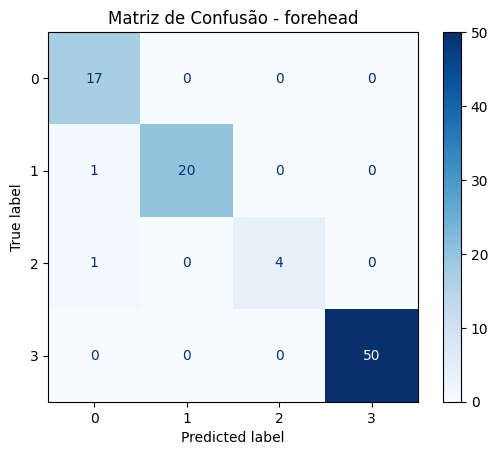


🌍 Testando região: chin


c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


              precision    recall  f1-score   support

           0       0.94      0.94      0.94       102
           1       0.94      0.94      0.94       139
           2       0.95      0.92      0.93        38
           3       0.96      0.98      0.97        50

    accuracy                           0.95       329
   macro avg       0.95      0.95      0.95       329
weighted avg       0.95      0.95      0.95       329



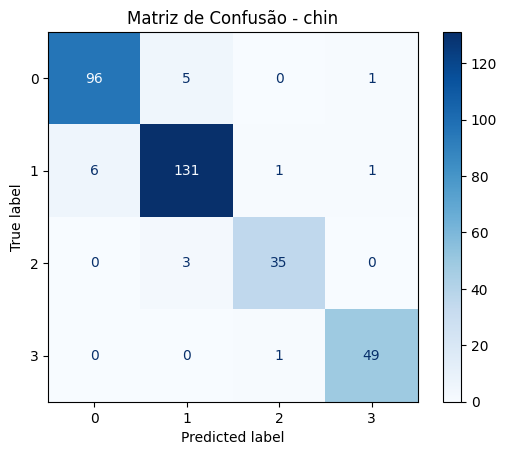


🌍 Testando região: nose


c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       0.96      0.93      0.95        28
           2       1.00      0.88      0.93         8
           3       1.00      1.00      1.00        50

    accuracy                           0.97       103
   macro avg       0.96      0.95      0.96       103
weighted avg       0.97      0.97      0.97       103



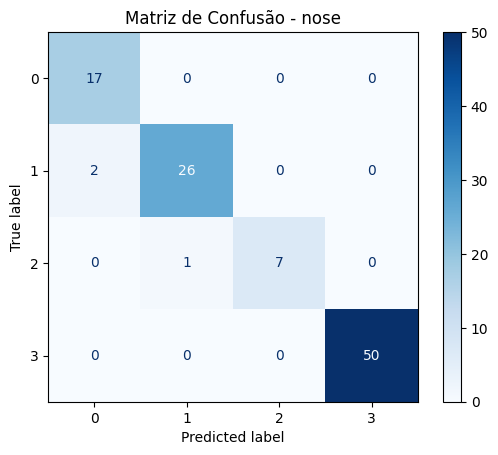


🌍 Testando região: left_cheek


c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.94      0.97      0.95        60
           2       0.94      0.88      0.91        17
           3       0.98      1.00      0.99        50

    accuracy                           0.95       169
   macro avg       0.95      0.94      0.94       169
weighted avg       0.95      0.95      0.95       169



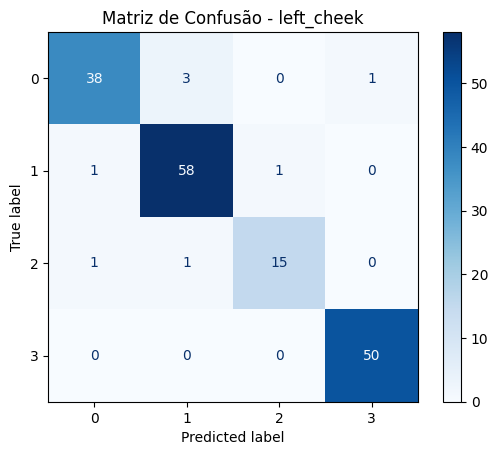


🌍 Testando região: right_cheek


c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       140
           1       0.98      0.96      0.97       164
           2       0.98      0.95      0.96        42
           3       0.98      1.00      0.99        50

    accuracy                           0.97       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.97      0.97      0.97       396



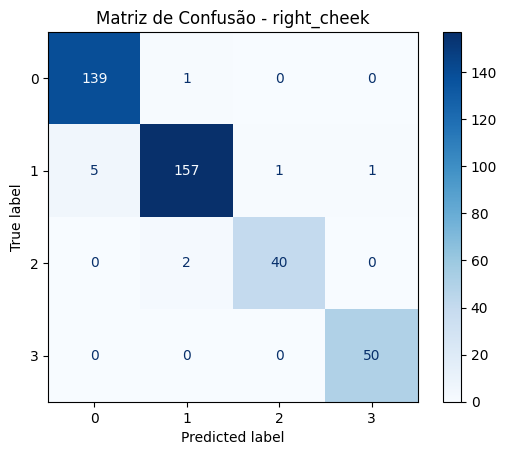

In [9]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

IMAGE_SIZE = 224
BATCH_SIZE = 16
REGIONS = ["forehead", "chin", "nose", "left_cheek", "right_cheek"]
BASE_PATH = "../../data/final"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformação para o teste
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

for region in REGIONS:
    print(f"\n🌍 Testando região: {region}")

    # Dataset de teste
    test_dir = os.path.join(BASE_PATH, region, 'test')
    test_ds = datasets.ImageFolder(test_dir, transform=test_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
    model_dir = os.path.join(parent_dir, "models")

    model_path = os.path.join(model_dir, f"resnet18_{region}_final.pth")

    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 4)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    # Avaliação
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Relatório
    print(classification_report(all_labels, all_preds, target_names=['0', '1', '2', '3']))

    # Matriz de confusão
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2', '3'])
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de Confusão - {region}")
    plt.show()
